In [26]:
import MoviDataset
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from matplotlib import patches
from torchvision import io
import torch
import numpy as np
from MoviTransforms import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:

path='/home/nfs/inf6/data/datasets/MOVi/movi_c/'

train_dataset = MoviDataset.MoviDataset(path, split='train') 
test_dataset= MoviDataset.MoviDataset(path, split='validation') 

BATCH_SIZE = 64

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE,
                          num_workers = 0,
                          shuffle=True
                          )

test_loader = DataLoader(dataset=test_dataset, 
                          batch_size=BATCH_SIZE,
                          num_workers = 0,
                          shuffle=False)

[INFO] - TRAIN Data Loaded: Coordinates: 9737, Masks: 9737, RGB videos:  9737, Flows:  9737
[INFO] - VALIDATION Data Loaded: Coordinates: 250, Masks: 250, RGB videos:  250, Flows:  250


### Images

In [12]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/rgb_00208_07.png'
rgb_image = io.read_image(path=path).to(torch.float32)
rgb_image.shape

torch.Size([3, 128, 128])

### Flow

In [13]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/flow_00208_07.png'
flow = io.read_image(path=path).to(torch.float32)
flow.shape

torch.Size([3, 128, 128])

### Masks

In [14]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/train/mask_00208.pt'
mask = torch.load(path, map_location="cpu")
mask['masks'].shape


torch.Size([24, 128, 128])

In [15]:
mask.keys()

dict_keys(['masks'])

In [16]:
print(mask['masks'].shape)
print(mask['masks'].unique())

torch.Size([24, 128, 128])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.uint8)


In [17]:
mask['masks'][9]

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)

### Coordinates

In [18]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/coords_00236.pt'
coord = torch.load(path, map_location="cpu")
print("Keys in loaded coord dict:", coord.keys())
print("Shape of coord['com']:", coord['com'].shape)
print("Shape of coord['bbox']:", coord['bbox'].shape)

Keys in loaded coord dict: dict_keys(['com', 'bbox'])
Shape of coord['com']: torch.Size([24, 11, 2])
Shape of coord['bbox']: torch.Size([24, 11, 4])


### Data Visualization

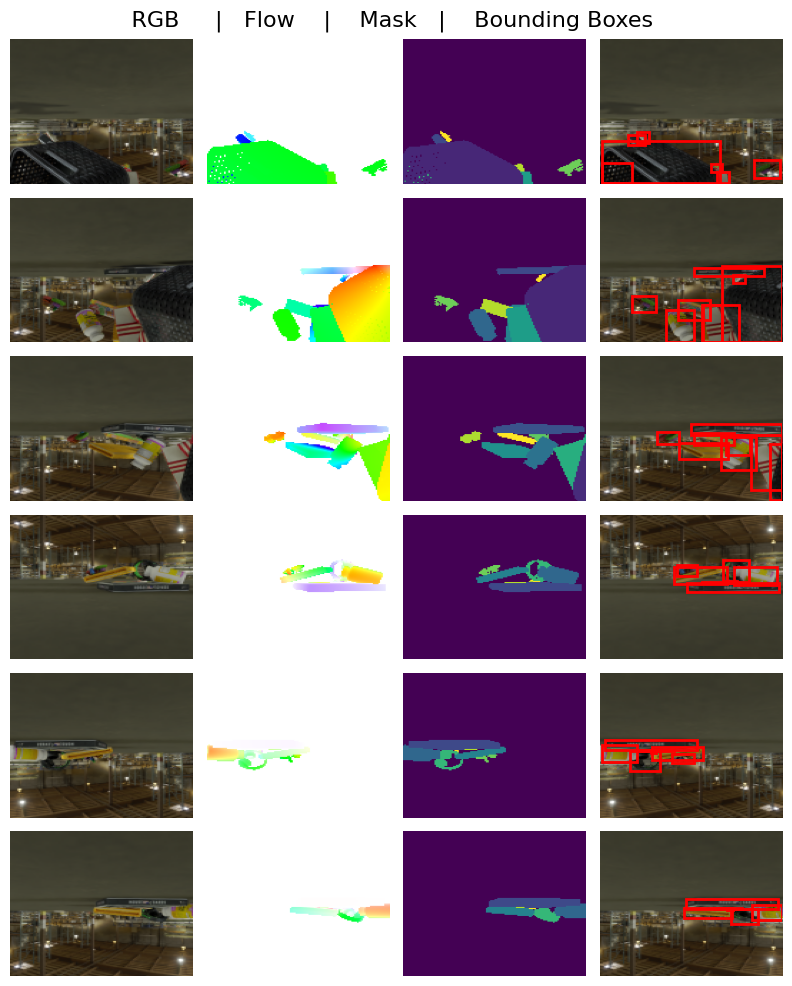

In [35]:
coords, masks, rgbs, flows = next(iter(test_loader))

idx = np.random.randint(0, BATCH_SIZE) #select a random video in the batch

video_frames_data = test_dataset.get_video_frame_labels(coords['com'][idx], 
                                                        coords['bbox'][idx], 
                                                        masks['masks'][idx], 
                                                        rgbs[idx], 
                                                        flows[idx])

# 24 frames x 4 columns (RGB, Flow, Mask, BBox)
fig, axes = plt.subplots(6, 4, figsize=(8, 10))
fig.suptitle('    RGB     |   Flow    |    Mask   |    Bounding Boxes     ', fontsize=16)

i = 0

transformed_data = ParameterCompose([RandomHorizontalFlip(0.7),RandomVerticalFlip(p=0.7)])

for frame_idx in range(1,len(video_frames_data),4):
# for frame_idx in range(len(video_frames_data)):

    coord, bbox, mask, rgb, flow = video_frames_data[frame_idx]
    coord, bbox, mask, rgb, flow=transformed_data((coord, bbox, mask, rgb, flow))
    # RGB image
    axes[i, 0].imshow((rgb).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 0].axis("off")
    # axes[i, 0].set_title(f"RGB Frame {frame_idx}")
    axes[i, 0].set_aspect('auto')
    
    # Flow image
    axes[i, 1].imshow((flow).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 1].axis("off")
    # axes[i, 1].set_title(f"Flow Frame {frame_idx}")
    axes[i, 1].set_aspect('auto')
    
    
    # Mask image
    axes[i, 2].imshow((mask).clamp(0, 255).byte().numpy())
    axes[i, 2].axis("off")
    # axes[i, 2].set_title(f"Mask Frame {frame_idx}")
    axes[i, 2].set_aspect('auto')
    
    
    # Bounding boxes visualization
    axes[i, 3].imshow((rgb).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 3].axis("off")
    # axes[i, 3].set_title(f"BBox Frame {frame_idx}")
    axes[i, 3].set_aspect('auto')
    

    # Draw bounding boxes
    for obj_idx in range(bbox.shape[0]):
        x1, y1, x2, y2 = bbox[obj_idx].tolist()
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
        axes[i, 3].add_patch(rect)

    i += 1
    
# Remove whitespace between columns and rows
plt.subplots_adjust(wspace=25, hspace=25)
plt.tight_layout(pad=1)
plt.show()


In [ ]:
## Verifying the dataloader  
for batch in test_loader:
    coords, masks, rgbs, flows = batch
    # print(coords.keys())
    print(f"RGBs shape: {rgbs.shape}\nFlows shape: {flows.shape}\nMasks shape: {masks['masks'].shape} \nCoords com shape: {coords['com'].shape}\nCoords bbxs shape: {coords['bbox'].shape}")
    break

In [ ]:
# from transformers import VivitModel, VivitConfig
# model = VivitModel.from_pretrained("google/vivit-b-16x2-kinetics400", attn_implementation="sdpa", dtype=torch.float16)


In [ ]:
# # Initializing a ViViT google/vivit-b-16x2-kinetics400 style configuration
# configuration = VivitConfig()

# # Initializing a model (with random weights) from the google/vivit-b-16x2-kinetics400 style configuration
# model = VivitModel(configuration)

# # Accessing the model configuration
# configuration = model.config

In [ ]:
# model

In [ ]:
# configuration